<a href="https://colab.research.google.com/github/QuocAnh288/My-1-Repo/blob/main/Olist_Churn_Prediction_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

# 1. Đọc các file dữ liệu vào Python (Giả sử file nằm ở thư mục gốc của Colab)
orders = pd.read_csv('Data/olist_orders_dataset.csv')
customers = pd.read_csv('Data/olist_customers_dataset.csv')
items = pd.read_csv('Data/olist_order_items_dataset.csv')
reviews = pd.read_csv('Data/olist_order_reviews_dataset.csv')
payments = pd.read_csv('Data/olist_order_payments_dataset.csv')

# --- CHIẾN LƯỢC KẾT HỢP (MERGE) ---

# Bước A: Nối Đơn hàng với Khách hàng để biết "Ai đã mua"
# Chúng ta dùng 'customer_id' làm cầu nối
master_df = pd.merge(orders, customers, on='customer_id', how='inner')

# Bước B: Nối tiếp với Chi tiết món hàng để biết "Mua cái gì và bao nhiêu tiền"
# Dùng 'order_id' làm cầu nối
master_df = pd.merge(master_df, items, on='order_id', how='left')

# Bước C: Nối với Đánh giá để biết "Khách có hài lòng không"
master_df = pd.merge(master_df, reviews, on='order_id', how='left')

# Bước D: Nối với Thanh toán để biết "Khách trả tiền bằng cách nào"
master_df = pd.merge(master_df, payments, on='order_id', how='left')

# 2. Kiểm tra kết quả
print("Kích thước bảng tổng hợp sau khi nối:", master_df.shape)
print("\nDanh sách các cột bạn đang có:")
print(master_df.columns.tolist())

# Hiển thị 5 dòng đầu tiên để kiểm tra
master_df.head()


Kích thước bảng tổng hợp sau khi nối: (119143, 28)

Danh sách các cột bạn đang có:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,1.0,credit_card,3.0,179.12


--- Tóm tắt các con số chính (Numerical Statistics) ---
               price  freight_value
count  118310.000000  118310.000000
mean      120.646603      20.032387
std       184.109691      15.836850
min         0.850000       0.000000
25%        39.900000      13.080000
50%        74.900000      16.280000
75%       134.900000      21.180000
max      6735.000000     409.680000


/tmp/ipykernel_355/3000495998.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=master_df, x='review_score', palette='viridis')


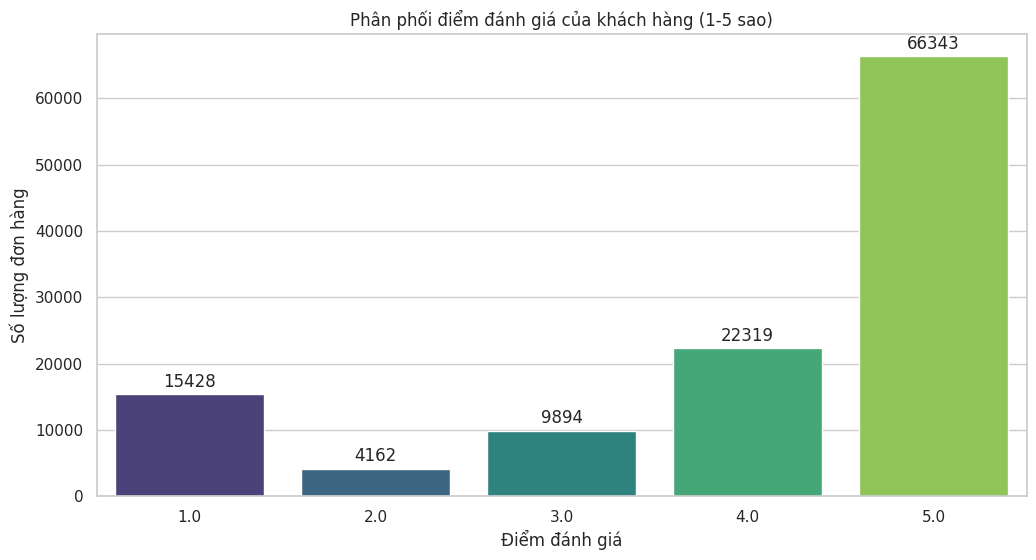

/tmp/ipykernel_355/3000495998.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=order_counts_filtered.index, y=order_counts_filtered.values, palette='magma')


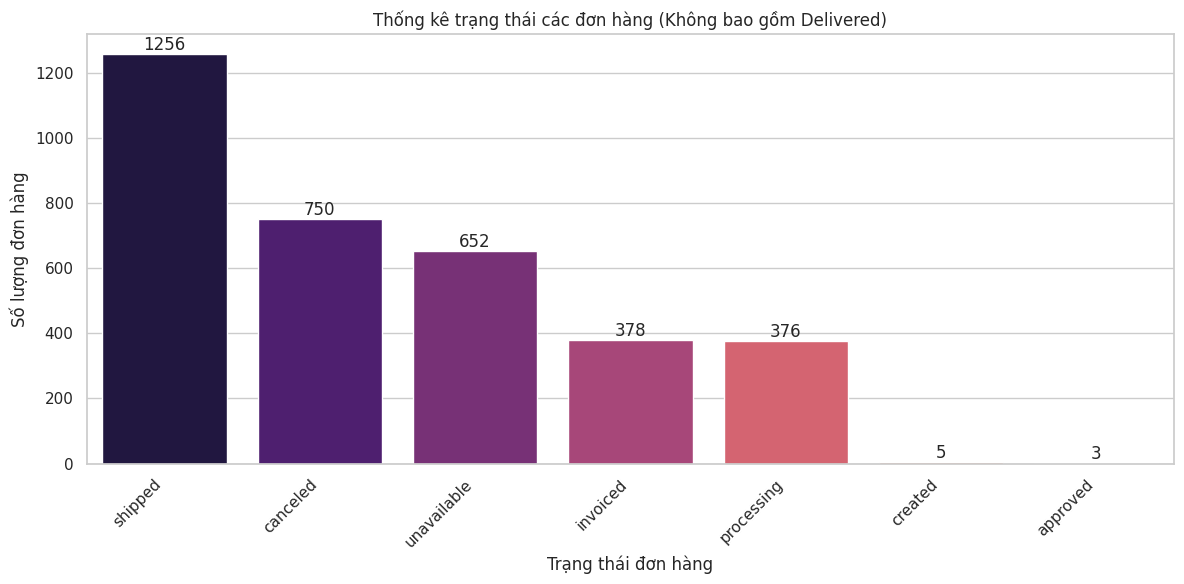

/tmp/ipykernel_355/3000495998.py:46: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_over_time = master_df.set_index('order_purchase_timestamp').resample('M')['order_id'].count()


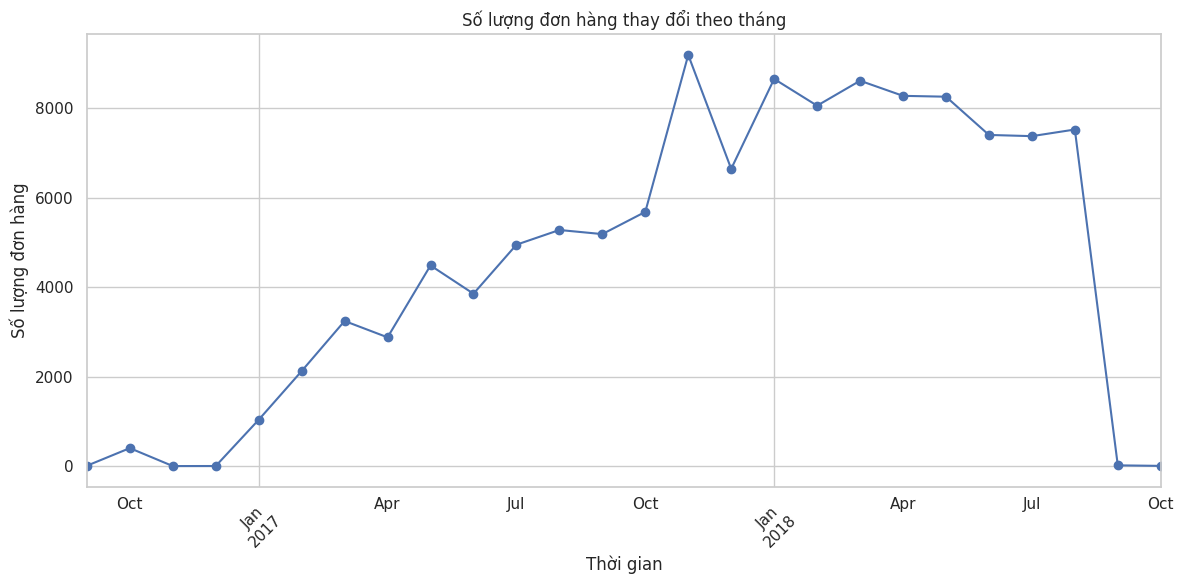

/tmp/ipykernel_355/3000495998.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(x=top_cities.values, y=top_cities.index, palette='rocket')


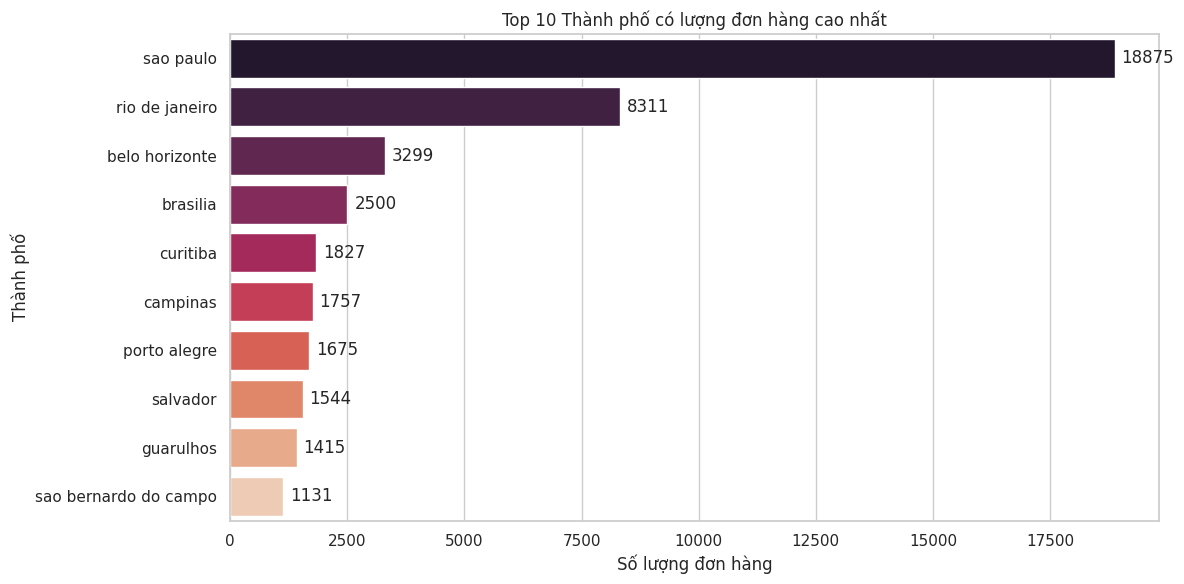

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập phong cách cho biểu đồ
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# --- 1. THỐNG KÊ MÔ TẢ CƠ BẢN ---
print("--- Tóm tắt các con số chính (Numerical Statistics) ---")
# Tính toán giá đơn hàng và phí ship trung bình
print(master_df[['price', 'freight_value']].describe())

# --- 2. VẼ BIỂU ĐỒ ---

# Biểu đồ 1: Phân phối điểm đánh giá (Review Score)
plt.figure()
ax1 = sns.countplot(data=master_df, x='review_score', palette='viridis')
plt.title('Phân phối điểm đánh giá của khách hàng (1-5 sao)')
plt.xlabel('Điểm đánh giá')
plt.ylabel('Số lượng đơn hàng')
# Thêm số liệu cụ thể lên trên mỗi cột
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9), textcoords = 'offset points')
plt.show()

# Biểu đồ 2: Trạng thái đơn hàng (Tạm bỏ "delivered" và thêm số liệu cụ thể)
plt.figure()
order_counts = master_df['order_status'].value_counts()
# Tạm bỏ trạng thái 'delivered'
order_counts_filtered = order_counts.drop(labels=['delivered'], errors='ignore')
ax2 = sns.barplot(x=order_counts_filtered.index, y=order_counts_filtered.values, palette='magma')
plt.title('Thống kê trạng thái các đơn hàng (Không bao gồm Delivered)')
plt.xlabel('Trạng thái đơn hàng')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(rotation=45, ha='right')
# Thêm số liệu cụ thể lên trên mỗi cột
for index, value in enumerate(order_counts_filtered.values):
    ax2.text(index, value + 0.1, str(value), ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Biểu đồ 3: Xu hướng mua sắm theo thời gian (Tháng) với nhãn rõ ràng hơn
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])
sales_over_time = master_df.set_index('order_purchase_timestamp').resample('M')['order_id'].count()

plt.figure()
sales_over_time.plot(marker='o', color='b')
plt.title('Số lượng đơn hàng thay đổi theo tháng')
plt.xlabel('Thời gian')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Biểu đồ 4: Top 10 Tỉnh/Thành phố có nhiều khách hàng nhất
plt.figure()
top_cities = master_df['customer_city'].value_counts().head(10)
ax4 = sns.barplot(x=top_cities.values, y=top_cities.index, palette='rocket')
plt.title('Top 10 Thành phố có lượng đơn hàng cao nhất')
plt.xlabel('Số lượng đơn hàng')
plt.ylabel('Thành phố')
# Thêm số liệu cụ thể lên trên mỗi cột
for p in ax4.patches:
    ax4.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha = 'left', va = 'center',
                xytext = (5, 0), textcoords = 'offset points')
plt.tight_layout()
plt.show()

/tmp/ipykernel_355/1073932689.py:12: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_analysis = master_df.set_index('order_purchase_timestamp').resample('Q').agg({
/tmp/ipykernel_355/1073932689.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=quarterly_analysis, x='quarter_label', y='price', palette='Blues_d')


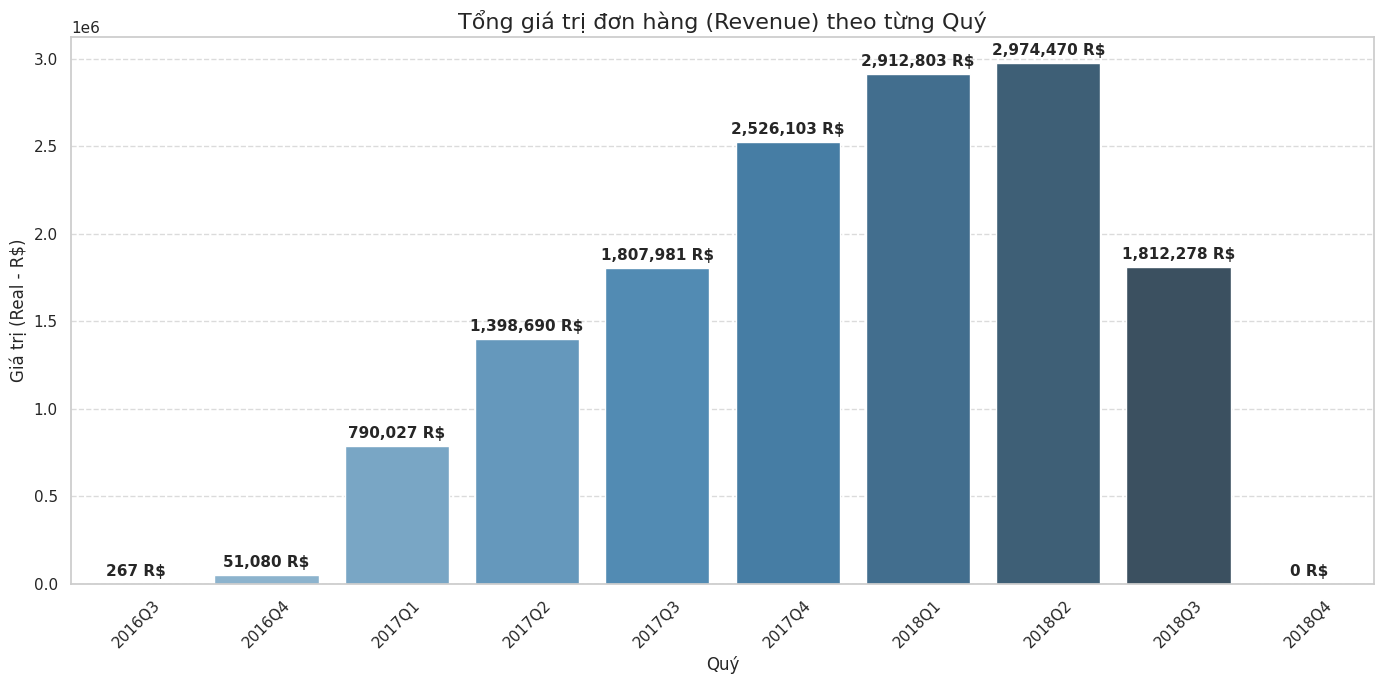

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
# Chỉ lấy dữ liệu trước tháng 08/2018 để đảm bảo các quý so sánh công bằng hơn
master_df_filtered = master_df[master_df['order_purchase_timestamp'] < '2018-08-01']

# Sau đó mới thực hiện vẽ biểu đồ theo quý như code cũ
# Đảm bảo cột thời gian đã đúng định dạng
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])

# Gom nhóm dữ liệu theo Quý ('Q')
# Chúng ta tính: Đếm số order_id và Tổng cột price
quarterly_analysis = master_df.set_index('order_purchase_timestamp').resample('Q').agg({
    'order_id': 'count',
    'price': 'sum'
}).reset_index()

# Tạo tên cột dễ hiểu cho Quý (VD: 2017Q1, 2017Q2...)
quarterly_analysis['quarter_label'] = quarterly_analysis['order_purchase_timestamp'].dt.to_period('Q').astype(str)

# --- VẼ BIỂU ĐỒ ---
plt.figure(figsize=(14, 7))

# Vẽ biểu đồ cột cho Tổng giá trị đơn hàng
ax = sns.barplot(data=quarterly_analysis, x='quarter_label', y='price', palette='Blues_d')
import matplotlib.pyplot as plt

# Sau khi vẽ xong biểu đồ...
plt.savefig('ten_file.png', dpi=300, bbox_inches='tight')
# dpi=300: Độ phân giải chuẩn in ấn, giúp ảnh cực kỳ sắc nét.
# bbox_inches='tight': Tự động cắt bỏ các khoảng trắng thừa xung quanh.
# Hiển thị giá trị cụ thể trên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f} R$',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.title('Tổng giá trị đơn hàng (Revenue) theo từng Quý', fontsize=16)
plt.xlabel('Quý', fontsize=12)
plt.ylabel('Giá trị (Real - R$)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_355/3961408848.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
/tmp/ipykernel_355/3961408848.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_products.values, y=bottom_products.index, palette='rocket')


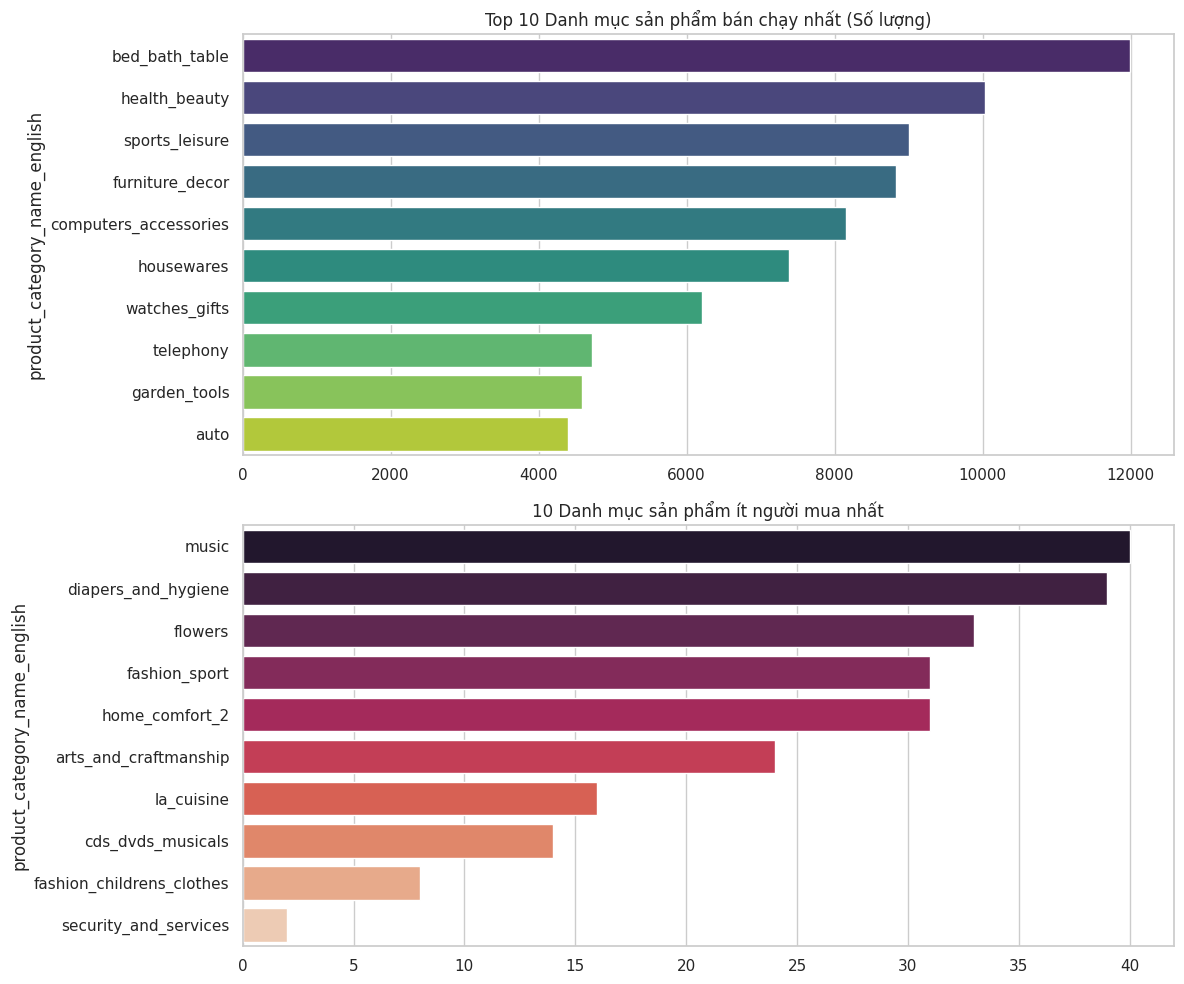

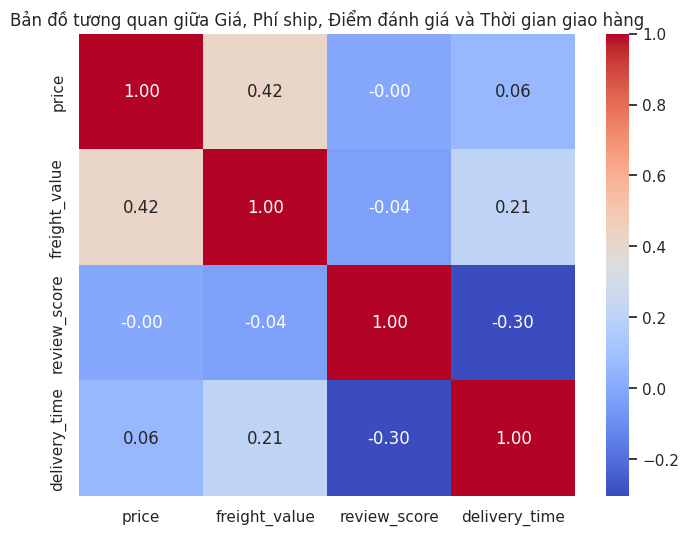

In [15]:
# 1. Chuẩn bị dữ liệu Sản phẩm (Cần chạy thêm bước này nếu chưa làm)
products = pd.read_csv('Data/olist_products_dataset.csv')
translation = pd.read_csv('Data/product_category_name_translation.csv')

# Nối bảng sản phẩm với bản dịch tên
products_translated = pd.merge(products, translation, on='product_category_name', how='left')

# Nối vào bảng master_df khổng lồ của chúng ta
master_df = pd.merge(master_df, products_translated[['product_id', 'product_category_name_english']], on='product_id', how='left')

# --- 2. PHÂN TÍCH SẢN PHẨM ---
plt.figure(figsize=(12, 10))

# Top 10 sản phẩm bán chạy nhất
plt.subplot(2, 1, 1)
top_products = master_df['product_category_name_english'].value_counts().head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Danh mục sản phẩm bán chạy nhất (Số lượng)')

# 10 sản phẩm ít người mua nhất (Lọc các loại có ít nhất 1 đơn)
plt.subplot(2, 1, 2)
bottom_products = master_df['product_category_name_english'].value_counts().tail(10)
sns.barplot(x=bottom_products.values, y=bottom_products.index, palette='rocket')
plt.title('10 Danh mục sản phẩm ít người mua nhất')
plt.tight_layout()
plt.show()

# --- 3. PHÂN TÍCH TƯƠNG QUAN (CORRELATION) ---
# Tính toán thời gian giao hàng thực tế (ngày)
master_df['delivery_time'] = (pd.to_datetime(master_df['order_delivered_customer_date']) -
                             pd.to_datetime(master_df['order_purchase_timestamp'])).dt.days

# Chọn các biến số quan trọng để xem mối quan hệ
corr_columns = ['price', 'freight_value', 'review_score', 'delivery_time']
corr_matrix = master_df[corr_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Bản đồ tương quan giữa Giá, Phí ship, Điểm đánh giá và Thời gian giao hàng')
plt.show()

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split # Import train_test_split

# --- 1. CHUẨN BỊ DỮ LIỆU ---
# Dự báo review_score (biến liên tục) thay vì biến phân loại
# Lấy các cột cần thiết từ master_df và loại bỏ các giá trị NaN để chuẩn bị cho mô hình
df_ml = master_df[['price', 'freight_value', 'delivery_time', 'review_score']].copy()
df_ml = df_ml.dropna(subset=['price', 'freight_value', 'delivery_time', 'review_score'])

X = df_ml[['price', 'freight_value', 'delivery_time']]
y = df_ml['review_score'] # Biến mục tiêu là điểm số thực tế

# Chia dữ liệu 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 2. HUẤN LUYỆN MÔ HÌNH ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# --- 3. DỰ ĐOÁN VÀ ĐÁNH GIÁ ---
y_pred = lr_model.predict(X_test)

print("--- KẾT QUẢ HỒI QUY TUYẾN TÍNH ---")
print(f"Hệ số chặn (Intercept): {lr_model.intercept_:.4f}")
print("Hệ số hồi quy (Coefficients):")
for i, v in enumerate(['Price', 'Freight', 'Delivery Time']):
    print(f" - {v}: {lr_model.coef_[i]:.4f}")

print(f"\nSai số bình phương trung bình (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"Hệ số xác định (R-squared): {r2_score(y_test, y_pred):.4f}")

--- KẾT QUẢ HỒI QUY TUYẾN TÍNH ---
Hệ số chặn (Intercept): 4.5625
Hệ số hồi quy (Coefficients):
 - Price: 0.0001
 - Freight: 0.0024
 - Delivery Time: -0.0447

Sai số bình phương trung bình (MSE): 1.6727
Hệ số xác định (R-squared): 0.0876


/tmp/ipykernel_355/1741762536.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Segment', data=rfm, palette='viridis', order=rfm['Segment'].value_counts().index)


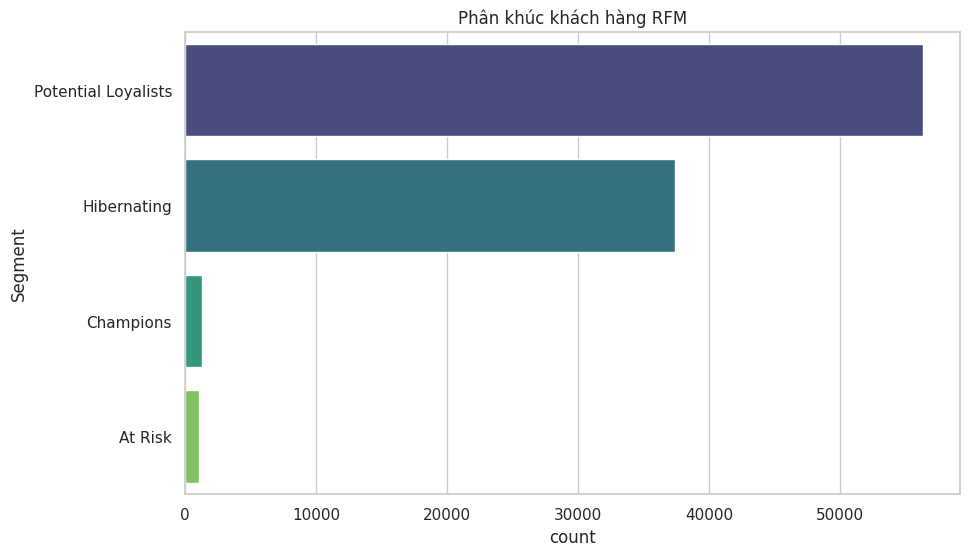

In [21]:
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tính toán các giá trị R, F, M
# Giả sử master_df đã được merge từ các bảng Orders, Items và Customers
now = master_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm = master_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (now - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).rename(columns={
    'order_purchase_timestamp': 'Recency',
    'order_id': 'Frequency',
    'price': 'Monetary'
})

# 2. Chấm điểm từ 1-5 (Dùng qcut cho R và M, Frequency tự định nghĩa do bị lệch)
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])
rfm['F_Score'] = rfm['Frequency'].apply(lambda x: 1 if x==1 else (2 if x==2 else 3))

# 3. Phân nhóm khách hàng
def fm_segment(df):
    r = int(df['R_Score'])
    f = int(df['F_Score'])
    if r >= 4 and f >= 2: return 'Champions'
    if r >= 3: return 'Potential Loyalists'
    if r <= 2 and f >= 2: return 'At Risk'
    return 'Hibernating'

rfm['Segment'] = rfm.apply(fm_segment, axis=1)

# 4. Vẽ biểu đồ phân khúc
plt.figure(figsize=(10,6))
sns.countplot(y='Segment', data=rfm, palette='viridis', order=rfm['Segment'].value_counts().index)
plt.title('Phân khúc khách hàng RFM')
plt.savefig('rfm_segments.png', bbox_inches='tight')
plt.show()